In [1]:
"""
This script reads geo data from a CSV file and processes it to create a rectangular grid of values.
The grid is then plotted as an image overlay on a map using matplotlib.

Steps:
1. Read the data from the CSV file.
2. Calculate the highest class per point.
3. Get the x and y values.
4. Get the unique x and y values.
5. Convert the coordinates to a different coordinate system.
6. Calculate the bounds of the data.
7. Create a 3D grid to store the class values.
8. Fill the 3D grid with the class values.
9. Create a 2D grid to store the index of the class with the highest value.
10. Create a 2D grid to store the maximum value.
11. Create a list of colormaps.
12. Create an empty image.
13. Color the points in the image based on the class values.
14. Plot the image.
15. Create a legend.
16. Save the plot as an image file.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from transformation import transform_csv

# read the data
df = pd.read_csv('upload_data/8-col-31468.csv')

# get then highest class per point
df['highest_class'] = df[['Class1', 'Class2', 'Class3', 'Class4', 'Class5', 'Class6']].idxmax(axis=1)

# get the x and y values
x = df['Easting (m)'].values
y = df['Northing (m)'].values

# get the unique values
x_unique = np.unique(x)
y_unique = np.unique(y)

# get the number of unique values
x_unique_len = len(x_unique)
y_unique_len = len(y_unique)

# get the bounds of df
x_min = df['Easting (m)'].min()
x_max = df['Easting (m)'].max()
y_min = df['Northing (m)'].min()
y_max = df['Northing (m)'].max()
print(f"old bounds: {x_min}, {x_max}, {y_min}, {y_max}")
# # convert the coordinates to a different coordinate system to get the bounds for the dash leaflet map
# trans_df = transform_csv('upload_data/8-col-31468.csv', 31468, 4326)
# # get the bounds
# x_min = trans_df['Latitude'].min()
# x_max = trans_df['Latitude'].max()
# y_min = trans_df['Longitude'].min()
# y_max = trans_df['Longitude'].max()
# print(f"old bounds: {x_min}, {x_max}, {y_min}, {y_max}")

old bounds: 5717200, 5750800, 4423900, 4466900


In [2]:
# Create the 3D grid
classes = ['Class1', 'Class2', 'Class3', 'Class4', 'Class5', 'Class6']
grid_3d = np.zeros((x_unique_len, y_unique_len, len(classes)))

# Convert DataFrame to numpy array for faster access
df_values = df[classes].values

# Create the 3D grid
grid_3d = np.zeros((x_unique_len, y_unique_len, len(classes)))

# Create a mapping from the unique x and y values to their indices
x_mapping = {value: i for i, value in enumerate(x_unique)}
y_mapping = {value: i for i, value in enumerate(y_unique)}

# Fill the 3D grid with the class values
for i in range(len(x)):
    x_index = x_mapping[x[i]]
    y_index = y_mapping[y[i]]
    grid_3d[x_index, y_index, :] = df_values[i]

# Replace zeros with NaN
grid_3d[grid_3d == 0] = np.nan

# Create the 2D grid that stores the index of the class with the highest value
grid_max_class = np.argmax(grid_3d, axis=2)

# Create the 2D grid that stores the maximum value
grid_max_value = np.max(grid_3d, axis=2)

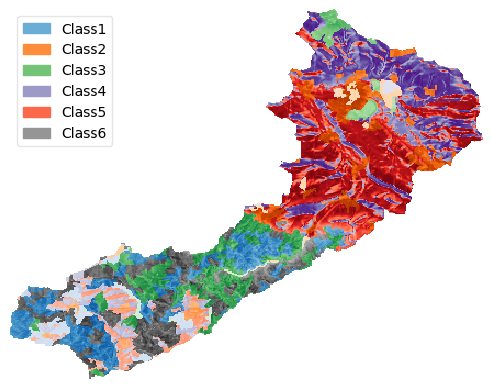

In [3]:
# Create the list of colormaps
cmaps = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, plt.cm.Purples, plt.cm.Reds, plt.cm.Greys]

# Create the empty image
image = np.zeros((x_unique_len, y_unique_len, 4))

# Color the points
for i, cmap in enumerate(cmaps):
    mask = (grid_max_class == i)
    image[mask] = cmap(grid_max_value[mask])

# Plot the image
fig, ax = plt.subplots(frameon=False)
ax.imshow(image, origin='lower', interpolation='none')
ax.axis('off')

# Create the legend
patches = [mpatches.Patch(color=cmap(0.5), label=class_) for cmap, class_ in zip(cmaps, classes)]
ax.legend(handles=patches, loc='upper left', framealpha=0.5)

plt.savefig('assets/test_1.png', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

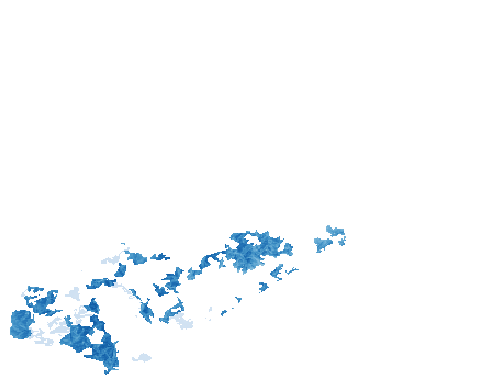

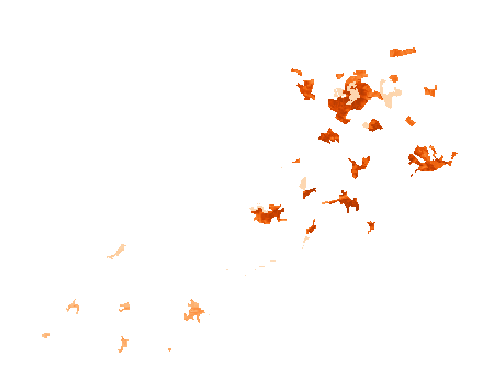

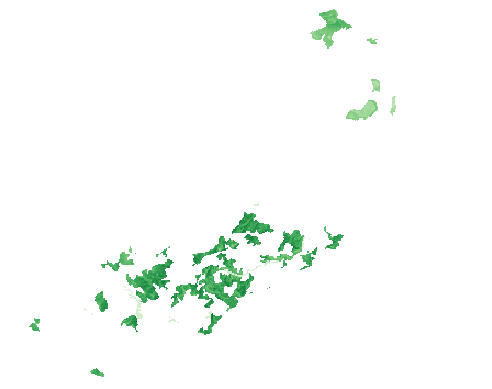

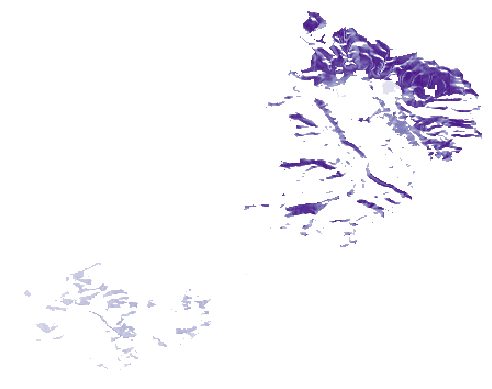

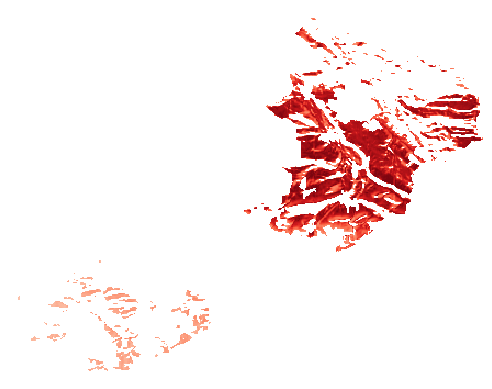

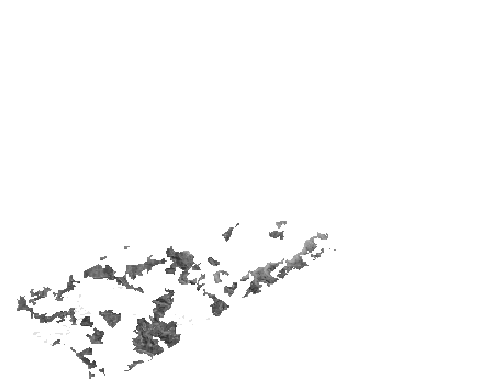

In [5]:
# make plots for every class separately and save them as images like above
for i, cmap in enumerate(cmaps):
    mask = (grid_max_class == i)
    image = np.zeros((x_unique_len, y_unique_len, 4))
    image[mask] = cmap(grid_max_value[mask])
    fig, ax = plt.subplots(frameon=False)
    ax.imshow(image, origin='lower', interpolation='none')
    ax.axis('off')
    plt.savefig(f'assets/class_{i+1}.png', bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()

In [16]:
import rasterio
from rasterio.transform import from_gcps
from rasterio.control import GroundControlPoint
from pyproj import CRS, Transformer

# Replace NaN values with 0
# image = np.nan_to_num(np.moveaxis(image, -1, 0))

# Define the GCPs
gcps = [
    GroundControlPoint(id='top_left', x=y_min, y=x_min, info='top left', row=0, col=0),  # top left
    GroundControlPoint(id='top_right', x=y_max, y=x_min, info='top right', row=0, col=image.shape[2]),  # top right
    GroundControlPoint(id='bottom_left', x=y_min, y=x_max, info='bottom left', row=image.shape[1], col= 0),  # bottom left
    GroundControlPoint(id='bottom_right', x=y_max, y=x_max, info='bottom right', row=image.shape[1], col=image.shape[2]),  # bottom right
]
print(f"gcsps 31468: {gcps}")
# transform the GCPs from 31468 to 4326
transformer = Transformer.from_crs(31468, 4326)
gcps = [GroundControlPoint(id=gcp.id, x=transformer.transform(gcp.y, gcp.x)[1], y=transformer.transform(gcp.y, gcp.x)[0], info=gcp.info, row=gcp.row, col=gcp.col) for gcp in gcps]
print(f"gcsps 4326: {gcps}")

transform = from_gcps(gcps)
crs = 'EPSG:4326'

with rasterio.open('output.tif', 'r+') as ds:
    ds.transform = transform
    ds.crs = crs
    ds.driver = 'GTiff'
    ds.nodata = 0
    ds.write(image)


gcsps 31468: [GroundControlPoint(row=0, col=0, x=4423900, y=5717200, id='top_left', info='top left'), GroundControlPoint(row=0, col=431, x=4466900, y=5717200, id='top_right', info='top right'), GroundControlPoint(row=337, col=0, x=4423900, y=5750800, id='bottom_left', info='bottom left'), GroundControlPoint(row=337, col=431, x=4466900, y=5750800, id='bottom_right', info='bottom right')]
gcsps 4326: [GroundControlPoint(row=0, col=0, x=10.900552564637886, y=51.58410626475426, id='top_left', info='top left'), GroundControlPoint(row=0, col=431, x=11.520897697061788, y=51.588273658596066, id='top_right', info='top right'), GroundControlPoint(row=337, col=0, x=10.893205786071572, y=51.88603805781338, id='bottom_left', info='bottom left'), GroundControlPoint(row=337, col=431, x=11.517698540816196, y=51.89025057851594, id='bottom_right', info='bottom right')]


In [6]:
# Define the GCPs
gcps = [
    GroundControlPoint(id='top_left', x=y_min, y=x_min, info='top left', row=0, col=0),  # top left
    GroundControlPoint(id='top_right', x=y_max, y=x_min, info='top right', row=0, col=image.shape[2]),  # top right
    GroundControlPoint(id='bottom_left', x=y_min, y=x_max, info='bottom left', row=image.shape[1], col= 0),  # bottom left
    GroundControlPoint(id='bottom_right', x=y_max, y=x_max, info='bottom right', row=image.shape[1], col=image.shape[2]),  # bottom right
]

# transform the GCPs from 31468 to 4326
transformer = Transformer.from_crs(31468, 4326)
gcps = [GroundControlPoint(id=gcp.id, x=transformer.transform(gcp.y, gcp.x)[1], y=transformer.transform(gcp.y, gcp.x)[0], info=gcp.info, row=gcp.row, col=gcp.col) for gcp in gcps]

# Write the GeoTIFF file with GCPs
with rasterio.open('output.tif', 'w', driver='GTiff', height=image.shape[1], width=image.shape[2], count=4, dtype=image.dtype, crs='EPSG:4326', gcps=(gcps, CRS.from_epsg(4326)), nodata=0) as dst:
    dst.write(image)

AttributeError: 'list' object has no attribute 'col'

In [50]:
import rasterio
from rasterio.transform import from_bounds

# Define the transformation
transform = from_bounds(y_min, x_max, y_max, x_min, image.shape[1], image.shape[0])

# Replace NaN values with 0
image = np.nan_to_num(np.moveaxis(image, -1, 0))

# Write the GeoTIFF file
with rasterio.open('output.tif', 'w', driver='GTiff', height=image.shape[1], width=image.shape[2], count=4, dtype=image.dtype, crs='EPSG:4326', transform=transform, nodata=0) as dst:
    dst.write(image)